# 冠状动脉斑块进展预测 — `all.csv` 预处理 + 建模

数据:`data/all.csv` —— 已经人工筛选/处理过的特征(基线临床 + 病变 CTA 影像 + PCAT + FFRct)。

**目标(二分类)**:`target_lesion_positive`(1 = 目标病变进展)。

## 工作流
1. 加载 & 列名清洗(乱码列 / 多余空格 / 空列)
2. 缺失值与分布快速 EDA
3. 类别变量编码(`artery_vessel` / `lesion_segment` / `contact_segment` One-Hot)
4. **按患者 `accession_id` 分组** 划分 Train / Val / Test(防止同一患者跨集泄漏)
5. 中位数填补 + StandardScaler(仅 `fit` 训练集)
6. 训练 4 个基线模型,统一处理类别不平衡:
   - Logistic Regression (`class_weight='balanced'`)
   - Random Forest (`class_weight='balanced'`)
   - XGBoost (`scale_pos_weight = neg/pos`)
   - LightGBM (`is_unbalance=True`)
7. Val/Test 上的 ROC-AUC / PR-AUC / F1 / 混淆矩阵
8. 最优模型 -> 特征重要性 / 校准曲线 / 阈值选择
9. 持久化 `processed/all/` 与 `models/`

In [1]:
import os, json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             classification_report, confusion_matrix,
                             roc_curve, precision_recall_curve, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
sns.set_style('whitegrid')
RNG = 42

DATA_PATH = 'data/all.csv'
OUT_DIR   = 'processed/all'
MOD_DIR   = 'models'
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(MOD_DIR, exist_ok=True)
print('OUT_DIR =', OUT_DIR)
print('MOD_DIR =', MOD_DIR)

OUT_DIR = processed/all
MOD_DIR = models


## 1. 加载 & 列名清洗
原始 CSV 中有一个乱码列名 `mean_hu��pcat_hu��`(实为 PCAT 平均 HU)、一个尾部空格的 `baseline_ldl_level `、一个空尾列 `Unnamed: 47`,以及含空格的 `High-Risk Plaque Flag`。统一规范化。

In [2]:
df = pd.read_csv(DATA_PATH)
print('原始 shape:', df.shape)

df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
rename_map = {}
for c in df.columns:
    new = c.strip()
    if 'pcat_hu' in new and 'mean_hu' in new:
        new = 'pcat_hu_mean'
    new = new.replace(' ', '_').replace('-', '_').lower()
    if new != c:
        rename_map[c] = new
df = df.rename(columns=rename_map)
print('重命名:'); print(json.dumps(rename_map, ensure_ascii=False, indent=2))
print('清洗后 shape:', df.shape)
df.head(3)

原始 shape: (2208, 48)
重命名:
{
  "baseline_ldl_level ": "baseline_ldl_level",
  "High-Risk Plaque Flag": "high_risk_plaque_flag",
  "mean_hu��pcat_hu��": "pcat_hu_mean"
}
清洗后 shape: (2208, 47)


,accession_id,artery_vessel,lesion_segment,contact_segment,target_lesion_positive,sex,age_years,history_hypertension,history_diabetes,history_smoking,history_pci,baseline_creatinine,baseline_crp,baseline_ldl,baseline_ldl_level,baseline_triglycerides,baseline_lipoprotein_a,baseline_hba1c,minimum_luminal_area_mm3,maximum_diameter_stenosis_percent,calcified_volume_ratio,non_calcified_plaque_burden,low_attenuation_plaque_burden,fibrous_fatty_mean_hu,fibrous_fatty_volume_mm3,fibrous_fatty_volume_ratio,fibrous_fatty_plaque_burden,fibrotic_mean_hu,fibrotic_volume_mm3,fibrotic_volume_ratio,fibrotic_plaque_burden,whole_lesion_volume_mm3,whole_lesion_plaque_burden,positive_remodeling_flag,low_attenuation_plaque_flag,napkin_ring_sign_flag,spotty_calcification_flag,plaque_feature_count,high_risk_plaque_flag,max_hu,min_hu,pcat_hu_mean,pcat_hu_high_risk_flag,std_hu,contact_volume_mm3,ffrct_value,ffrct_risk_class
0,ZS0025103467,LCX,LCX-Proximal,LCX-Proximal,0,1,76,1.0,1,0,1,82.0,0.88,1.919,2.0,2.51,5.0,6.4,0.491233,0.803510,0.400685,0.017850,0.000102,90,4.965194,0.178082,0.005304,218,11.649109,0.417808,0.012444,27.881474,0.029784,0,0,0,0,0,0,-30,-188,-85.31,0,34.76,160.80,0.88,1
1,ZS0025103467,RCA,RCA-Middle,RCA-Middle,0,1,76,1.0,1,0,1,82.0,0.88,1.919,2.0,2.51,5.0,6.4,3.359748,0.503452,0.425039,0.033305,0.000716,91,15.754943,0.127512,0.007386,221,53.757773,0.435085,0.025203,123.556943,0.057926,0,0,0,0,0,0,-30,-190,-94.90,0,41.17,534.33,0.90,1
2,ZS0025294556,LAD,LAD-Middle,LAD-Proximal,0,1,65,1.0,0,1,0,70.0,2.01,0.852,0.0,1.03,22.7,5.3,5.367708,0.283460,0.143822,0.077017,0.000955,87,38.234518,0.358108,0.032213,200,52.044290,0.487452,0.043848,106.768088,0.089954,1,1,0,0,2,0,-30,-184,-67.97,1,24.87,733.15,0.87,1


## 2. 快速 EDA

病变数: 2208    患者数: 1314
每患者病变数分布: {1: 650, 2: 462, 3: 177, 4: 22, 5: 3}

类别分布:
target_lesion_positive
0    1868
1     340
Name: count, dtype: int64
阳性率: 15.40%


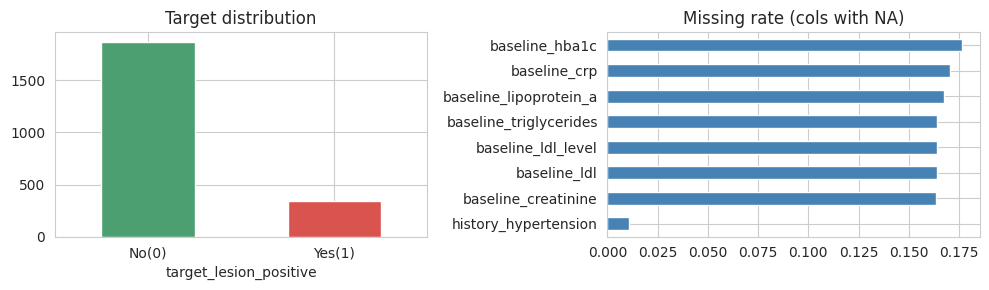

In [3]:
TARGET = 'target_lesion_positive'
ID_COL = 'accession_id'

print(f'病变数: {len(df)}    患者数: {df[ID_COL].nunique()}')
print(f'每患者病变数分布: {df.groupby(ID_COL).size().value_counts().sort_index().to_dict()}')
print(f'\n类别分布:\n{df[TARGET].value_counts()}')
print(f'阳性率: {df[TARGET].mean():.2%}')

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
df[TARGET].value_counts().plot.bar(ax=ax[0], color=['#4C9F70', '#D9534F'])
ax[0].set_title('Target distribution'); ax[0].set_xticklabels(['No(0)','Yes(1)'], rotation=0)
miss = df.isna().mean()
miss = miss[miss > 0].sort_values()
miss.plot.barh(ax=ax[1], color='steelblue')
ax[1].set_title('Missing rate (cols with NA)')
plt.tight_layout(); plt.show()

In [4]:
num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
desc = df[num_cols_all].describe().T[['mean','std','min','50%','max']]
desc.round(3).head(15)

,mean,std,min,50%,max
target_lesion_positive,0.154,0.361,0.00,0.000,1.00
sex,0.774,0.419,0.00,1.000,1.00
age_years,63.687,9.299,33.00,65.000,87.00
history_hypertension,0.696,0.460,0.00,1.000,1.00
history_diabetes,0.370,0.483,0.00,0.000,1.00
history_smoking,0.415,0.493,0.00,0.000,1.00
history_pci,0.167,0.373,0.00,0.000,1.00
baseline_creatinine,83.369,56.729,0.00,78.000,1237.60
baseline_crp,3.791,7.330,0.00,1.250,84.24
baseline_ldl,1.861,0.810,0.23,1.739,5.04


## 3. 分类变量 One-Hot

In [5]:
ONEHOT_COLS = ['artery_vessel', 'lesion_segment', 'contact_segment']
for c in ONEHOT_COLS:
    print(f'{c}: {sorted(df[c].unique())}')

df_enc = pd.get_dummies(df, columns=ONEHOT_COLS, prefix=ONEHOT_COLS, drop_first=False, dtype='int8')
print('编码后 shape:', df_enc.shape)

feature_cols = [c for c in df_enc.columns if c not in [TARGET, ID_COL]]
print(f'特征数: {len(feature_cols)}')

artery_vessel: ['LAD', 'LCX', 'RCA']
lesion_segment: ['LAD-Middle', 'LAD-Proximal', 'LCX-Middle', 'LCX-Proximal', 'RCA-Middle', 'RCA-Proximal']
contact_segment: ['LAD-Middle', 'LAD-Proximal', 'LCX-Middle', 'LCX-Proximal', 'RCA-Middle', 'RCA-Proximal']
编码后 shape: (2208, 59)
特征数: 57


## 4. 按患者分组的 Train/Val/Test 划分(60/20/20)

同一 `accession_id` 的多条病变记录必须落在同一份数据中,避免泄漏。

In [6]:
groups = df_enc[ID_COL].values
y      = df_enc[TARGET].values.astype(int)
X_full = df_enc[feature_cols].copy()

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RNG)
trainval_idx, test_idx = next(gss1.split(X_full, y, groups))

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RNG)
tv_groups = groups[trainval_idx]
tr_rel, val_rel = next(gss2.split(X_full.iloc[trainval_idx], y[trainval_idx], tv_groups))
train_idx = trainval_idx[tr_rel]
val_idx   = trainval_idx[val_rel]

for name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
    print(f'{name:5s}  n={len(idx):4d}  patients={df_enc.iloc[idx][ID_COL].nunique():4d}  pos_rate={y[idx].mean():.2%}')

assert set(df_enc.iloc[train_idx][ID_COL]).isdisjoint(set(df_enc.iloc[val_idx][ID_COL]))
assert set(df_enc.iloc[train_idx][ID_COL]).isdisjoint(set(df_enc.iloc[test_idx][ID_COL]))
assert set(df_enc.iloc[val_idx][ID_COL]).isdisjoint(set(df_enc.iloc[test_idx][ID_COL]))
print('\n✓ 三套数据的患者集合互不重叠')

Train  n=1395  patients= 840  pos_rate=16.06%
Val    n= 364  patients= 211  pos_rate=13.46%
Test   n= 449  patients= 263  pos_rate=14.92%

✓ 三套数据的患者集合互不重叠


## 5. 缺失值填补 + 标准化(仅 fit 训练集)

- 数值列:中位数填补;连续列 StandardScaler。
- 二值/独热列保留原值,不缩放。

In [7]:
X_tr_raw, X_val_raw, X_te_raw = X_full.iloc[train_idx].copy(), X_full.iloc[val_idx].copy(), X_full.iloc[test_idx].copy()
y_tr, y_val, y_te = y[train_idx], y[val_idx], y[test_idx]

imputer = SimpleImputer(strategy='median')
X_tr  = pd.DataFrame(imputer.fit_transform(X_tr_raw),  columns=feature_cols, index=X_tr_raw.index)
X_val = pd.DataFrame(imputer.transform(X_val_raw),     columns=feature_cols, index=X_val_raw.index)
X_te  = pd.DataFrame(imputer.transform(X_te_raw),      columns=feature_cols, index=X_te_raw.index)

binary_like = [c for c in feature_cols if X_tr[c].nunique() <= 2]
cont_cols   = [c for c in feature_cols if c not in binary_like]
print(f'连续列 {len(cont_cols)}  二值列 {len(binary_like)}')

scaler = StandardScaler()
X_tr_s, X_val_s, X_te_s = X_tr.copy(), X_val.copy(), X_te.copy()
X_tr_s[cont_cols]  = scaler.fit_transform(X_tr[cont_cols])
X_val_s[cont_cols] = scaler.transform(X_val[cont_cols])
X_te_s[cont_cols]  = scaler.transform(X_te[cont_cols])

print('已生成:')
print('  · 树模型版本   X_tr / X_val / X_te        (中位数填补,未缩放)')
print('  · 线性模型版本 X_tr_s / X_val_s / X_te_s  (中位数填补 + 标准化)')

连续列 31  二值列 26
已生成:
  · 树模型版本   X_tr / X_val / X_te        (中位数填补,未缩放)
  · 线性模型版本 X_tr_s / X_val_s / X_te_s  (中位数填补 + 标准化)


## 6. 建模:LR / RF / XGB / LGBM
全部启用类别权重补偿(阳性率 ≈ 15%)。

In [8]:
neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
spw = neg / pos
print(f'Train  neg={neg}  pos={pos}  scale_pos_weight={spw:.3f}')

models = {
    'LogReg': (LogisticRegression(max_iter=2000, class_weight='balanced',
                                  solver='lbfgs', C=1.0, random_state=RNG),
               (X_tr_s, X_val_s, X_te_s)),
    'RandomForest': (RandomForestClassifier(n_estimators=500, max_depth=None,
                                            min_samples_leaf=2, class_weight='balanced',
                                            n_jobs=-1, random_state=RNG),
                     (X_tr, X_val, X_te)),
    'XGBoost': (xgb.XGBClassifier(n_estimators=600, max_depth=4, learning_rate=0.05,
                                  subsample=0.9, colsample_bytree=0.9,
                                  scale_pos_weight=spw, eval_metric='auc',
                                  tree_method='hist', random_state=RNG, n_jobs=-1),
                (X_tr, X_val, X_te)),
    'LightGBM': (lgb.LGBMClassifier(n_estimators=800, max_depth=-1, num_leaves=63,
                                    learning_rate=0.03, subsample=0.9, colsample_bytree=0.9,
                                    is_unbalance=True, random_state=RNG, n_jobs=-1, verbose=-1),
                 (X_tr, X_val, X_te)),
}

results = []
trained = {}
for name, (clf, (Xtr, Xv, Xt)) in models.items():
    clf.fit(Xtr, y_tr)
    p_val = clf.predict_proba(Xv)[:, 1]
    p_te  = clf.predict_proba(Xt)[:, 1]
    row = {
        'model':     name,
        'val_auc':   roc_auc_score(y_val, p_val),
        'val_ap':    average_precision_score(y_val, p_val),
        'val_f1@.5': f1_score(y_val, (p_val >= 0.5).astype(int)),
        'test_auc':  roc_auc_score(y_te,  p_te),
        'test_ap':   average_precision_score(y_te,  p_te),
        'test_f1@.5':f1_score(y_te,  (p_te  >= 0.5).astype(int)),
    }
    results.append(row)
    trained[name] = (clf, p_val, p_te)
    print(f"{name:12s}  val AUC={row['val_auc']:.3f}  PR-AUC={row['val_ap']:.3f}  F1={row['val_f1@.5']:.3f}")

res_df = pd.DataFrame(results).set_index('model').round(4)
res_df

Train  neg=1171  pos=224  scale_pos_weight=5.228
LogReg        val AUC=0.529  PR-AUC=0.214  F1=0.213


RandomForest  val AUC=0.607  PR-AUC=0.187  F1=0.000


XGBoost       val AUC=0.589  PR-AUC=0.174  F1=0.113


LightGBM      val AUC=0.581  PR-AUC=0.175  F1=0.071


,val_auc,val_ap,val_f1@.5,test_auc,test_ap,test_f1@.5
model,,,,,,
LogReg,0.5294,0.2144,0.2132,0.6263,0.2609,0.3248
RandomForest,0.6066,0.1875,0.0000,0.6712,0.2813,0.0000
XGBoost,0.5888,0.1745,0.1127,0.6616,0.2511,0.1348
LightGBM,0.5806,0.1747,0.0714,0.6643,0.2838,0.0822


## 7. ROC / PR 曲线对比

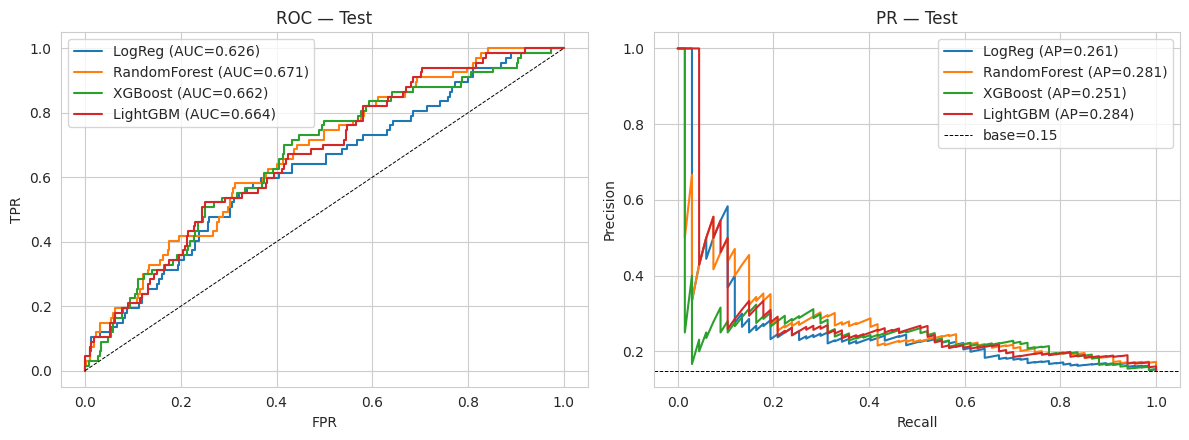

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for name, (clf, p_val, p_te) in trained.items():
    fpr, tpr, _ = roc_curve(y_te, p_te)
    pre, rec, _ = precision_recall_curve(y_te, p_te)
    ax[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_te,p_te):.3f})")
    ax[1].plot(rec, pre, label=f"{name} (AP={average_precision_score(y_te,p_te):.3f})")
ax[0].plot([0,1],[0,1],'k--',lw=.7); ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR'); ax[0].set_title('ROC — Test'); ax[0].legend()
ax[1].axhline(y_te.mean(),color='k',ls='--',lw=.7,label=f'base={y_te.mean():.2f}')
ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision'); ax[1].set_title('PR — Test'); ax[1].legend()
plt.tight_layout(); plt.show()

## 8. 最优模型:阈值选择 / 混淆矩阵 / 特征重要性
依据 **Val ROC-AUC** 选择最佳模型。然后在 Val 上搜索使 F1 最大的阈值,在 Test 报告最终指标。

★ Best model = RandomForest


Val 最优阈值 = 0.19  (F1=0.276)

Test classification report (thr=0.19):
              precision    recall  f1-score   support

          No      0.905     0.576     0.704       382
         Yes      0.214     0.657     0.322        67

    accuracy                          0.588       449
   macro avg      0.559     0.616     0.513       449
weighted avg      0.802     0.588     0.647       449



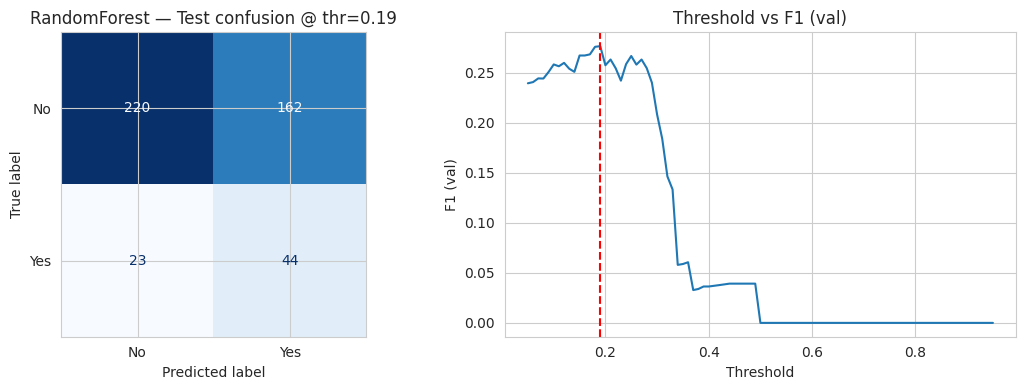

In [10]:
best_name = res_df['val_auc'].idxmax()
print('★ Best model =', best_name)
best_clf, p_val_b, p_te_b = trained[best_name]

thrs = np.linspace(0.05, 0.95, 91)
f1s = [f1_score(y_val, (p_val_b >= t).astype(int)) for t in thrs]
best_thr = thrs[int(np.argmax(f1s))]
print(f'Val 最优阈值 = {best_thr:.2f}  (F1={max(f1s):.3f})')

y_te_pred = (p_te_b >= best_thr).astype(int)
print('\nTest classification report (thr={:.2f}):'.format(best_thr))
print(classification_report(y_te, y_te_pred, digits=3, target_names=['No','Yes']))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_te_pred), display_labels=['No','Yes']).plot(ax=ax[0], colorbar=False, cmap='Blues')
ax[0].set_title(f'{best_name} — Test confusion @ thr={best_thr:.2f}')
ax[1].plot(thrs, f1s); ax[1].axvline(best_thr, color='r', ls='--')
ax[1].set_xlabel('Threshold'); ax[1].set_ylabel('F1 (val)'); ax[1].set_title('Threshold vs F1 (val)')
plt.tight_layout(); plt.show()

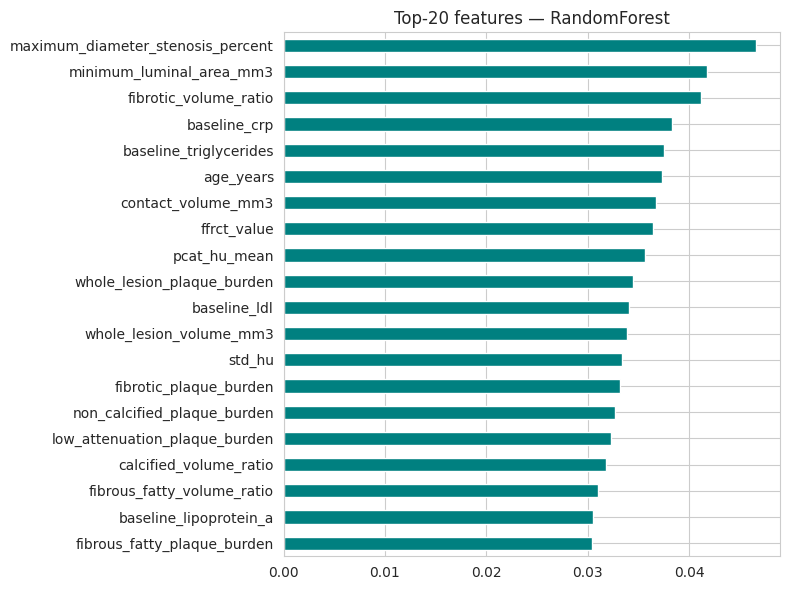

maximum_diameter_stenosis_percent    0.0466
minimum_luminal_area_mm3             0.0418
fibrotic_volume_ratio                0.0412
baseline_crp                         0.0383
baseline_triglycerides               0.0375
age_years                            0.0373
contact_volume_mm3                   0.0367
ffrct_value                          0.0365
pcat_hu_mean                         0.0357
whole_lesion_plaque_burden           0.0345
baseline_ldl                         0.0340
whole_lesion_volume_mm3              0.0339
std_hu                               0.0334
fibrotic_plaque_burden               0.0331
non_calcified_plaque_burden          0.0327
low_attenuation_plaque_burden        0.0322
calcified_volume_ratio               0.0318
fibrous_fatty_volume_ratio           0.0310
baseline_lipoprotein_a               0.0305
fibrous_fatty_plaque_burden          0.0304


In [11]:
if hasattr(best_clf, 'feature_importances_'):
    imp = pd.Series(best_clf.feature_importances_, index=feature_cols).sort_values(ascending=True)
elif hasattr(best_clf, 'coef_'):
    imp = pd.Series(np.abs(best_clf.coef_[0]), index=feature_cols).sort_values(ascending=True)
else:
    imp = None

if imp is not None:
    top = imp.tail(20)
    fig, ax = plt.subplots(figsize=(8, 6))
    top.plot.barh(ax=ax, color='teal')
    ax.set_title(f'Top-20 features — {best_name}')
    plt.tight_layout(); plt.show()
    print(top.iloc[::-1].head(20).round(4).to_string())

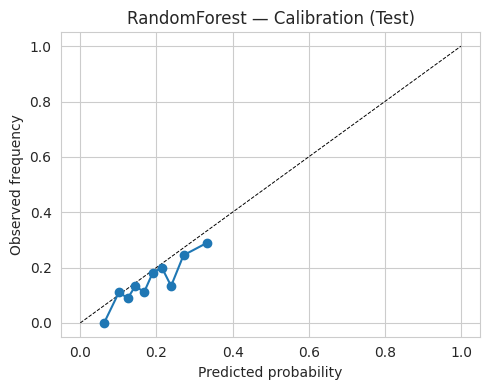

In [12]:
prob_true, prob_pred = calibration_curve(y_te, p_te_b, n_bins=10, strategy='quantile')
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot([0,1],[0,1],'k--',lw=.7)
ax.plot(prob_pred, prob_true, 'o-')
ax.set_xlabel('Predicted probability'); ax.set_ylabel('Observed frequency')
ax.set_title(f'{best_name} — Calibration (Test)')
plt.tight_layout(); plt.show()

## 9. 持久化

In [13]:
X_tr.to_parquet(os.path.join(OUT_DIR, 'X_train.parquet'))
X_val.to_parquet(os.path.join(OUT_DIR, 'X_val.parquet'))
X_te.to_parquet(os.path.join(OUT_DIR, 'X_test.parquet'))
X_tr_s.to_parquet(os.path.join(OUT_DIR, 'X_train_scaled.parquet'))
X_val_s.to_parquet(os.path.join(OUT_DIR, 'X_val_scaled.parquet'))
X_te_s.to_parquet(os.path.join(OUT_DIR, 'X_test_scaled.parquet'))
np.save(os.path.join(OUT_DIR, 'y_train.npy'), y_tr)
np.save(os.path.join(OUT_DIR, 'y_val.npy'),   y_val)
np.save(os.path.join(OUT_DIR, 'y_test.npy'),  y_te)
joblib.dump({'imputer': imputer, 'scaler': scaler,
             'feature_cols': feature_cols, 'cont_cols': cont_cols,
             'binary_cols': binary_like, 'rename_map': rename_map,
             'onehot_cols': ONEHOT_COLS},
            os.path.join(OUT_DIR, 'preprocessor.joblib'))

for name, (clf, _, _) in trained.items():
    joblib.dump(clf, os.path.join(MOD_DIR, f'{name}.joblib'))
joblib.dump({'best_model': best_name, 'best_threshold': float(best_thr),
             'results': res_df.reset_index().to_dict(orient='records')},
            os.path.join(MOD_DIR, 'meta.joblib'))
res_df.to_csv(os.path.join(MOD_DIR, 'results.csv'))
print('Saved preprocessed arrays to', OUT_DIR)
print('Saved models / metadata to', MOD_DIR)
print('Best:', best_name, '  threshold =', round(best_thr, 3))

Saved preprocessed arrays to processed/all
Saved models / metadata to models
Best: RandomForest   threshold = 0.19
